In [ ]:
!pip install pandas nltk textblob matplotlib seaborn


In [ ]:
import pandas as pd
import numpy as np
import nltk
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import re


nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Stats_EAS508/Tweets.csv')
# Display the first few rows
df.head()


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [ ]:
print(df.columns)


Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')


In [ ]:
# Check the size of the dataset
dataset_size = df.shape
print(f"The dataset has {dataset_size[0]} rows and {dataset_size[1]} columns.")


The dataset has 27481 rows and 4 columns.


In [ ]:
# Remove duplicates and null values
df.drop_duplicates(inplace=True)
df.dropna(subset=['text'], inplace=True)

# Text preprocessing function
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercasing
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    # Remove special characters and numbers
    text = re.sub(r'\d+|[^\w\s]', '', text)
    # Remove stopwords
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)

# Apply preprocessing
df['cleaned_comment'] = df['text'].apply(preprocess_text)


In [ ]:
# Sentiment analysis function
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

# Apply sentiment analysis
df['sentiment_score'] = df['cleaned_comment'].apply(get_sentiment)

# Categorize sentiment
df['sentiment'] = df['sentiment_score'].apply(lambda score: 'positive' if score > 0 else ('negative' if score < 0 else 'neutral'))

# Display processed data
df[['text', 'cleaned_comment', 'sentiment_score', 'sentiment']].head()


,text,cleaned_comment,sentiment_score,sentiment
0,"I`d have responded, if I were going",id responded going,0.0,neutral
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego,-0.5,negative
2,my boss is bullying me...,boss bullying,0.0,neutral
3,what interview! leave me alone,interview leave alone,0.0,neutral
4,"Sons of ****, why couldn`t they put them on t...",sons couldnt put releases already bought,0.0,neutral


In [ ]:
def get_sentiment_score(text):
    # Use TextBlob to calculate sentiment polarity (-1 to 1)
    return TextBlob(text).sentiment.polarity

# Apply the function to the 'text' column to get sentiment scores
df['sentiment_score'] = df['text'].apply(get_sentiment_score)

# Show the dataset with sentiment scores
print(df)

           textID                                               text  \
0      cb774db0d1                I`d have responded, if I were going   
1      549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2      088c60f138                          my boss is bullying me...   
3      9642c003ef                     what interview! leave me alone   
4      358bd9e861   Sons of ****, why couldn`t they put them on t...   
...           ...                                                ...   
27476  4eac33d1c0   wish we could come see u on Denver  husband l...   
27477  4f4c4fc327   I`ve wondered about rake to.  The client has ...   
27478  f67aae2310   Yay good for both of you. Enjoy the break - y...   
27479  ed167662a5                         But it was worth it  ****.   
27480  6f7127d9d7     All this flirting going on - The ATG smiles...   

                                           selected_text sentiment  \
0                    I`d have responded, if I were going   neutra

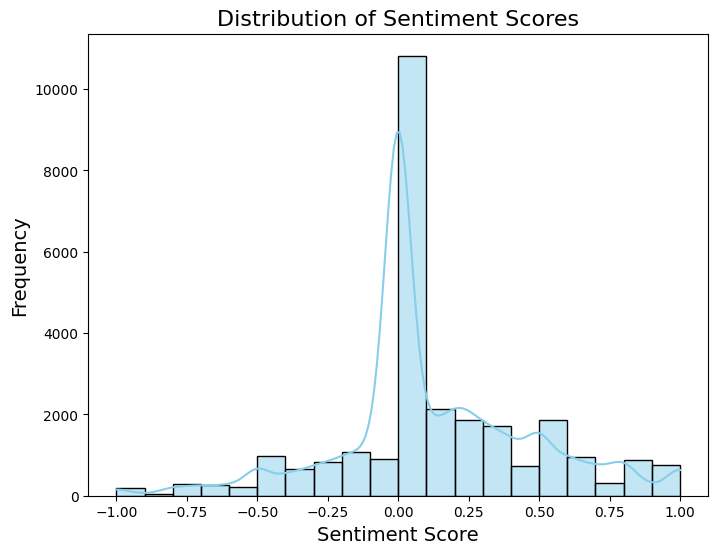

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the sentiment scores distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['sentiment_score'], bins=20, kde=True, color='skyblue', edgecolor='black')

# Adding labels and title
plt.title('Distribution of Sentiment Scores', fontsize=16)
plt.xlabel('Sentiment Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Show the plot
plt.show()


<ipython-input-15-57417417837c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


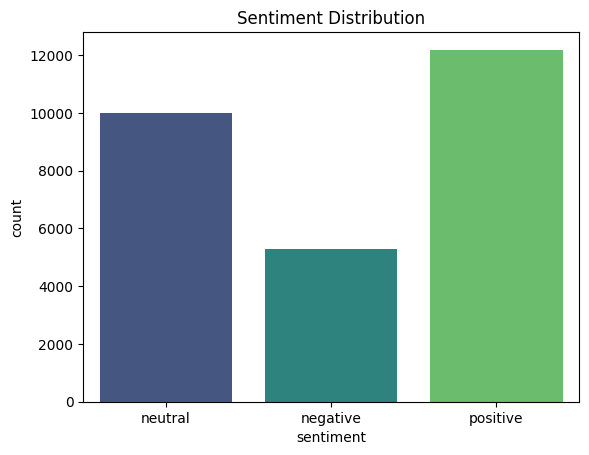

In [ ]:
# Plotting the distribution of sentiments
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title("Sentiment Distribution")
plt.show()


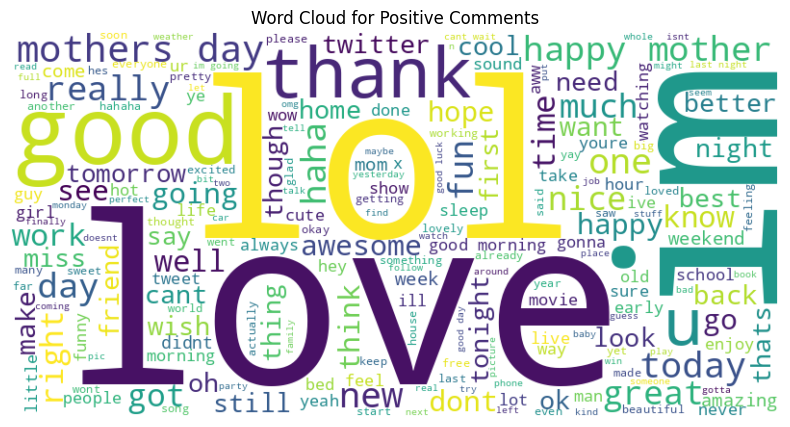

In [ ]:
from wordcloud import WordCloud

# Word cloud for positive comments
positive_comments = " ".join(df[df['sentiment'] == 'positive']['cleaned_comment'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_comments)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Positive Comments")
plt.show()
